<a href="https://colab.research.google.com/github/Balachandar-Ganesan/DeepLearning/blob/main/100_DeepLearningRaw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('seaborn-whitegrid')
import seaborn as sns
sns.set_style("whitegrid")
def shuffle_rows(data):
  """
  This function shuffles the row of the input dataframe.
  Input: data (pandas.DataFrame or ndarra)
  Output: shuffled data (ndarray)
  """
  # Convert input dataframe to ndarray
  data = np.array(data)
  np.random.shuffle(data)
  return data

def normalize_pixels(data):
  return data/255.

def init_params(layers_dims):
  params = {}
  for layer in range(1,len(layers_dims)):
    params['W'+str(layer)] = np.random.randn(layers_dims[layer], layers_dims[layer-1]) * np.sqrt(1. / layers_dims[layer])
    params['b'+str(layer)] = np.random.randn(layers_dims[layer],1) * np.sqrt(1. / layers_dims[layer])

  return params

def relu(Z):
  return np.maximum(Z,0)

def softmax(Z):
  A = np.exp(Z) / sum(np.exp(Z))
  return A

def deriv_relu(Z):
  return Z > 0

def deriv_softmax(Z):
    dZ = np.exp(Z) / sum(np.exp(Z)) * (1. - np.exp(Z) / sum(np.exp(Z)))
    return dZ

def one_hot(Y):
  """
  Y should have shape n,1 where n is the number of classes.
  Y comes in integer form (e.g. 4) and should be converted in binary shape:
  Y = [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]^T
  """
  # create temporary zeros array of shape (m,n), where m is the number
  # of training examples in Y, n is the number of classes in Y
  Y_one_hot = np.zeros((Y.shape[0], Y.max()+1))
  # set to 1 the corret indices
  Y_one_hot[np.arange(Y.shape[0]), Y] = 1
  # transpose
  Y_one_hot = Y_one_hot.T
  return Y_one_hot

def forward_prop(X, params):
  """
  Forward propagation for the L layers.
  First (L-1) layers: relu activation
  Last layer: softmax activation
  """
  # number of layers (note: params contains W and b for each layer, so it's necessary to do //2)
  L = len(params) // 2

  activations = {}
  activations['A0'] = X

  # for layers 1 to L-1 apply relu activation
  for l in range(1,L):
    activations['Z'+str(l)] = np.dot(params['W'+str(l)], activations['A'+str(l-1)]) + params['b'+str(l)]
    activations['A'+str(l)] = relu(activations['Z'+str(l)])

  # for layer L apply softmax activation
  activations['Z'+str(L)] = np.dot(params['W'+str(L)], activations['A'+str(L-1)]) + params['b'+str(L)]
  activations['A'+str(L)] = softmax(activations['Z'+str(L)])

  return activations


def back_prop(activations, params, Y):
  """
  Inputs:
  activations: dictionary like {'A0':..., 'A1':..., 'Z1':..., 'A2':..., ...}
  params: dictionary like {'W1':..., 'b1':..., 'W2':...}
  Y
  Output:
  grads: dictionary like {'dW1':..., 'db1':..., ...}
  """

  L = len(params) // 2
  one_hot_Y = one_hot(Y)
  m = one_hot_Y.shape[1]

  derivatives = {}
  grads = {}

  # for layer L
  derivatives['dZ'+str(L)] = (activations['A'+str(L)] - one_hot_Y)
  grads['dW'+str(L)] = 1 / m * np.dot(derivatives['dZ'+str(L)], activations['A'+str(L-1)].T)
  grads['db'+str(L)] = 1 / m * np.sum(derivatives['dZ'+str(L)])

  # for layers L-1 to 1
  for l in reversed(range(1, L)):
    derivatives['dZ'+str(l)] = np.dot(params['W'+str(l+1)].T, derivatives['dZ'+str(l+1)]) * deriv_relu(activations['Z'+str(l)])
    grads['dW'+str(l)] = 1 / m * np.dot(derivatives['dZ'+str(l)], activations['A'+str(l-1)].T)
    grads['db'+str(l)] = 1 / m * np.sum(derivatives['dZ'+str(l)], axis=1, keepdims=True)

  return grads

def update_params(params, grads, alpha):
  # number of layers
  L = len(params) // 2

  params_updated = {}
  for l in range(1, L+1):
    params_updated['W'+str(l)] = params['W'+str(l)] - alpha*grads['dW'+str(l)]
    params_updated['b'+str(l)] = params['b'+str(l)] - alpha*grads['db'+str(l)]

  return params_updated

def cross_entropy(Y_one_hot, Y_hat, epsilon=1e-12):
  """
  Compute cross entropy between target Y_one_hot (encoded as one-hot vector)
  and predictions Y_hat.
  Inputs: Y_one_hot (k, m) ndarray
          Y_hat (k, m) ndarray
          k: number of classes
          N: number of samples
  Output: cross entropy (scalar)
  sources:
    code: https://stackoverflow.com/questions/47377222/what-is-the-problem-with-my-implementation-of-the-cross-entropy-function
    formula: https://medium.com/unpackai/cross-entropy-loss-in-ml-d9f22fc11fe0#:~:text=Cross%2Dentropy%20can%20be%20calculated,*%20log(Q(x))
  """

  # clip predictions to avoid values of 0 and 1
  Y_hat = np.clip(Y_hat, epsilon, 1.-epsilon)
  # sum on the columns of Y_hat * np.log(Y), then take the mean
  # between the m samples
  cross_entropy = -np.mean(np.sum(Y_one_hot * np.log(Y_hat), axis=0))
  return cross_entropy

def get_predictions(AL):
  # get the max index by the columns
  return np.argmax(AL, axis=0)

def get_accuracy(Y_hat, Y):
  """
  Given the predicted classes Y_hat and the actual classes Y, returns the accuracy of the prediction
  Input:
  Y_hat (1,m) ndarray
  Y (1,m) ndarray
  Output:
  accuracy (scalar)
  """
  return np.sum(Y_hat == Y) / Y.size

def gradient_descent_optimization(X, Y, layers_size, max_iter, alpha):
  # initiallize parameters Wl, bl for layers l=1,...,L
  params = init_params(layers_size)
  L = len(params)//2
  accuracies = []
  losses = []
  for iter in range(1,max_iter+1):
    # compute activations: forward propagation
    activations = forward_prop(X, params)
    # make prediction
    Y_hat = get_predictions(activations['A'+str(L)])
    # compute accuracy
    accuracy = get_accuracy(Y_hat, Y)
    accuracies.append(accuracy)

    # compute loss (cross_entropy)
    loss = cross_entropy(one_hot(Y), activations['A'+str(L)])
    losses.append(loss)

    # compute gradients: back propagation
    grads = back_prop(activations, params, Y)

    # update the parameters
    params = update_params(params, grads, alpha)

    if iter % 10 == 0:
      print('Accuracy at iter {}: {}'.format(iter, accuracy))

  # plot training accuracy and loss
  plt.plot(range(1, max_iter+1), accuracies, '-', color=sns.color_palette('deep')[0], linewidth=2, label='Training Accuracy')
  plt.plot(range(1, max_iter+1), losses, ':', color=sns.color_palette('deep')[2], linewidth=2, label='Training Loss')
  plt.title("Network's Architecture: {}".format(layers_size))
  plt.legend(loc="upper right")
  plt.xlabel("X axis label")
  plt.savefig('training_acc_loss_{}.png'.format(layers_size), format='png', dpi=1200)

  return params

In [2]:
!wget https://raw.githubusercontent.com/Balachandar-Ganesan/DeepLearning/refs/heads/main/train.csv

--2026-03-04 01:34:22--  https://raw.githubusercontent.com/Balachandar-Ganesan/DeepLearning/refs/heads/main/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16792553 (16M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  16.01M  46.9MB/s    in 0.3s    

2026-03-04 01:34:24 (46.9 MB/s) - ‘train.csv’ saved [16792553/16792553]



Accuracy at iter 10: 0.7210569327158812
Accuracy at iter 20: 0.7541541814219559
Accuracy at iter 30: 0.7928357395804958
Accuracy at iter 40: 0.8586216289839281
Accuracy at iter 50: 0.8888586216289839
Accuracy at iter 60: 0.9043857259602288
Accuracy at iter 70: 0.8740125306456007
Accuracy at iter 80: 0.9207300463089076
Accuracy at iter 90: 0.9278125851266685
Accuracy at iter 100: 0.9317624625442659
Accuracy at iter 110: 0.9366657586488695
Accuracy at iter 120: 0.9396622173794607
Accuracy at iter 130: 0.9402070280577499
Accuracy at iter 140: 0.9381639880141651
Accuracy at iter 150: 0.9468809588667938
Accuracy at iter 160: 0.9504222282756742
Accuracy at iter 170: 0.953282484336693
Accuracy at iter 180: 0.9565513484064287
Accuracy at iter 190: 0.958321983110869
Accuracy at iter 200: 0.9599564151457368
Accuracy at iter 210: 0.9613184418414601
Accuracy at iter 220: 0.9622718605284664
Accuracy at iter 230: 0.963361481885045
Accuracy at iter 240: 0.9639062925633343
Accuracy at iter 250: 0.9658

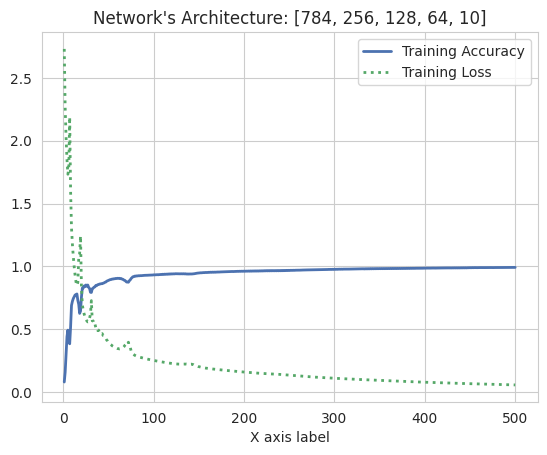

In [6]:
import numpy as np
import pandas as pd


def main():
  # load training data
  df_train = pd.read_csv('/content/train.csv')

  # shuffle the data
  df_train = shuffle_rows(df_train)

  # split train and validation set
  train_val_split = 0.8
  train_size = round(df_train.shape[0] * train_val_split)
  data_train = df_train[:train_size,:].T
  data_val = df_train[train_size:,:].T

  # divide input features and target feature
  X_train = data_train[1:]
  y_train = data_train[0]
  X_val = df_train[1:]
  y_val = df_train[0]

  # normalize training and val sets
  X_train = normalize_pixels(X_train)
  X_val = normalize_pixels(X_val)

  # set network and optimizer parameters
  layers_dims = [784, 256, 128, 64, 10]
  # layers_dims = [784, 10, 10]
  max_iter = 500
  alpha = 0.1

  # train the network
  params = gradient_descent_optimization(X_train, y_train, layers_dims, max_iter, alpha)

if __name__ == '__main__':
  main()
